# Lectura de datos

In [2]:
import pandas as pd
df=pd.read_csv("heart2.csv") #Leemos el csv
df.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# Anáisis de datos

In [3]:
sex_rep={
    "F": 0,
    "M": 1
}
cp_rep={
    "TA": 0,
    "ATA": 1,
    "NAP": 2,
    "ASY": 3
}
restecg_rep={
    "Normal": 0,
    "ST": 1,
    "LVH": 2
}
exang_rep={
    "Y": 1,
    "N": 0
}
slp_rep={
    "Down": 0,
    "Flat": 1,
    "Up": 2
}

rep_d={
    "Sex": sex_rep,
    "ChestPainType": cp_rep,
    "RestingECG": restecg_rep,
    "ExerciseAngina": exang_rep,
    "ST_Slope": slp_rep
}

In [4]:
import numpy as np
for col, rep in rep_d.items():
    df[col] = df[col].replace(rep)
df.head()

C:\Users\tinch\AppData\Local\Temp\ipykernel_17696\1213309271.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(rep)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,0,172,0,0.0,2,0
1,49,0,2,160,180,0,0,156,0,1.0,1,1
2,37,1,1,130,283,0,1,98,0,0.0,2,0
3,48,0,3,138,214,0,0,108,1,1.5,1,1
4,54,1,2,150,195,0,0,122,0,0.0,2,0


In [5]:
df.describe()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,0.789760,2.251634,132.396514,198.799564,0.233115,0.603486,136.809368,0.404139,0.887364,1.361656,0.553377
std,9.432617,0.407701,0.931031,18.514154,109.384145,0.423046,0.805968,25.460334,0.490992,1.066570,0.607056,0.497414
min,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,2.000000,120.000000,173.250000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,3.000000,130.000000,223.000000,0.000000,0.000000,138.000000,0.000000,0.600000,1.000000,1.000000
75%,60.000000,1.000000,3.000000,140.000000,267.000000,0.000000,1.000000,156.000000,1.000000,1.500000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,1.000000


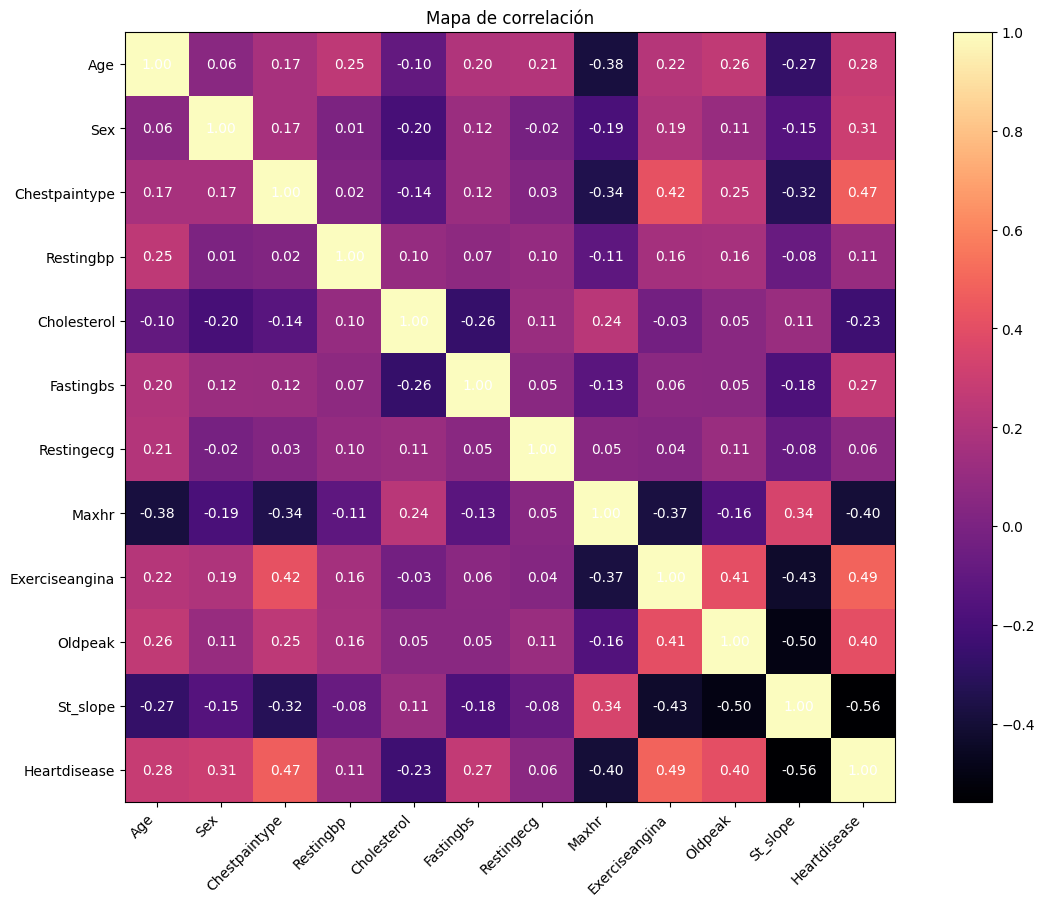

In [6]:
import numpy as np
import matplotlib.pyplot as plt

#separamos las columnas y ponemos mayuscula
labels = [label.capitalize() for label in df.columns.to_list()]


# crear la figura y los ejes
fig, ax = plt.subplots(figsize=(15, 10))

# Seteamaos el mapa de calor 
cax = ax.imshow(df.corr().to_numpy(), cmap='magma')
#Guardamos las correlaciones del df
corr_matrix=df.corr().to_numpy()
# Seteamos los visual 
ax.set_title('Mapa de correlación')
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels, ha='right')
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', color='white')
# Agregamos la escala de color
fig.colorbar(cax, ax=ax)

plt.show()

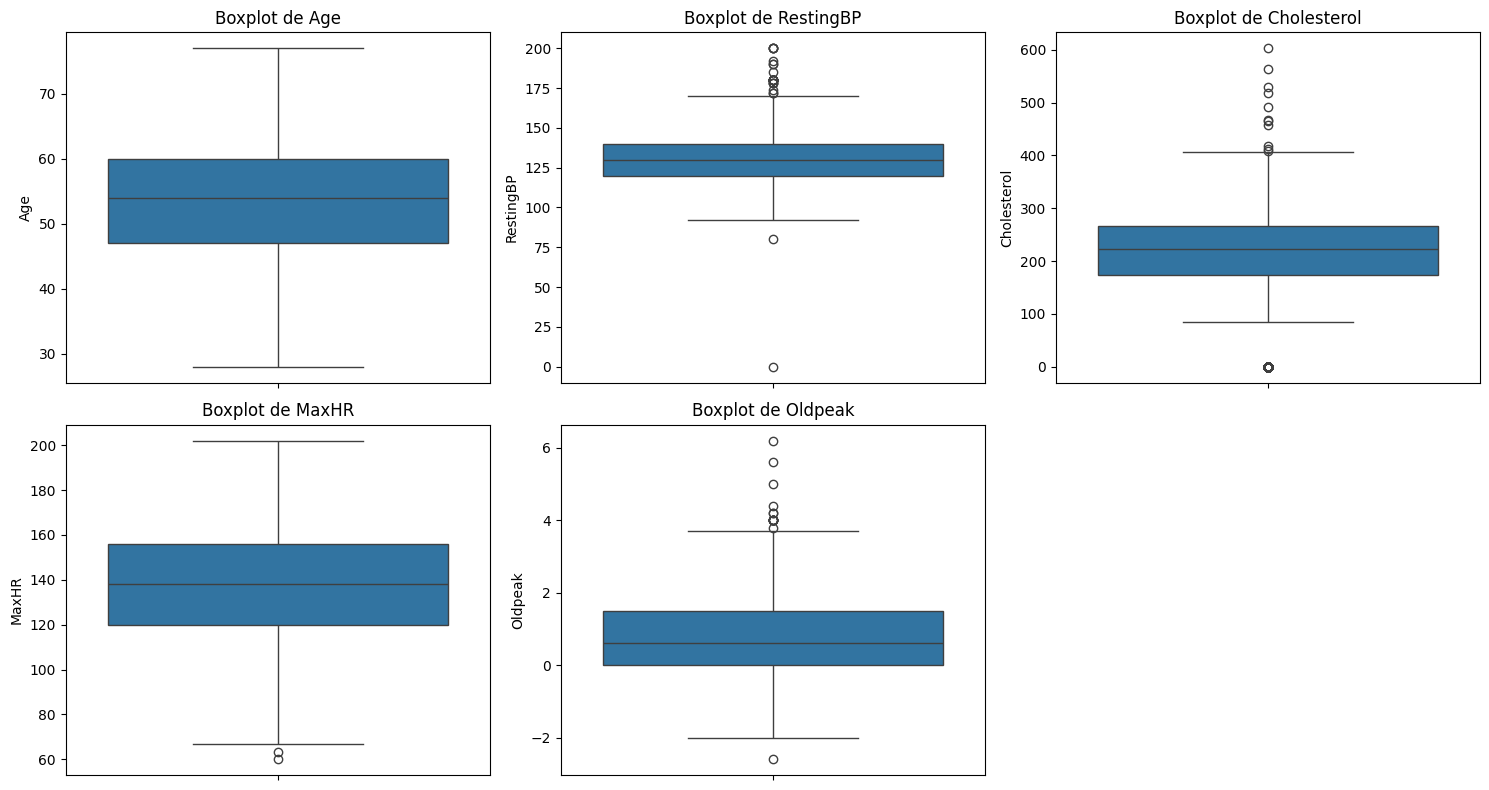

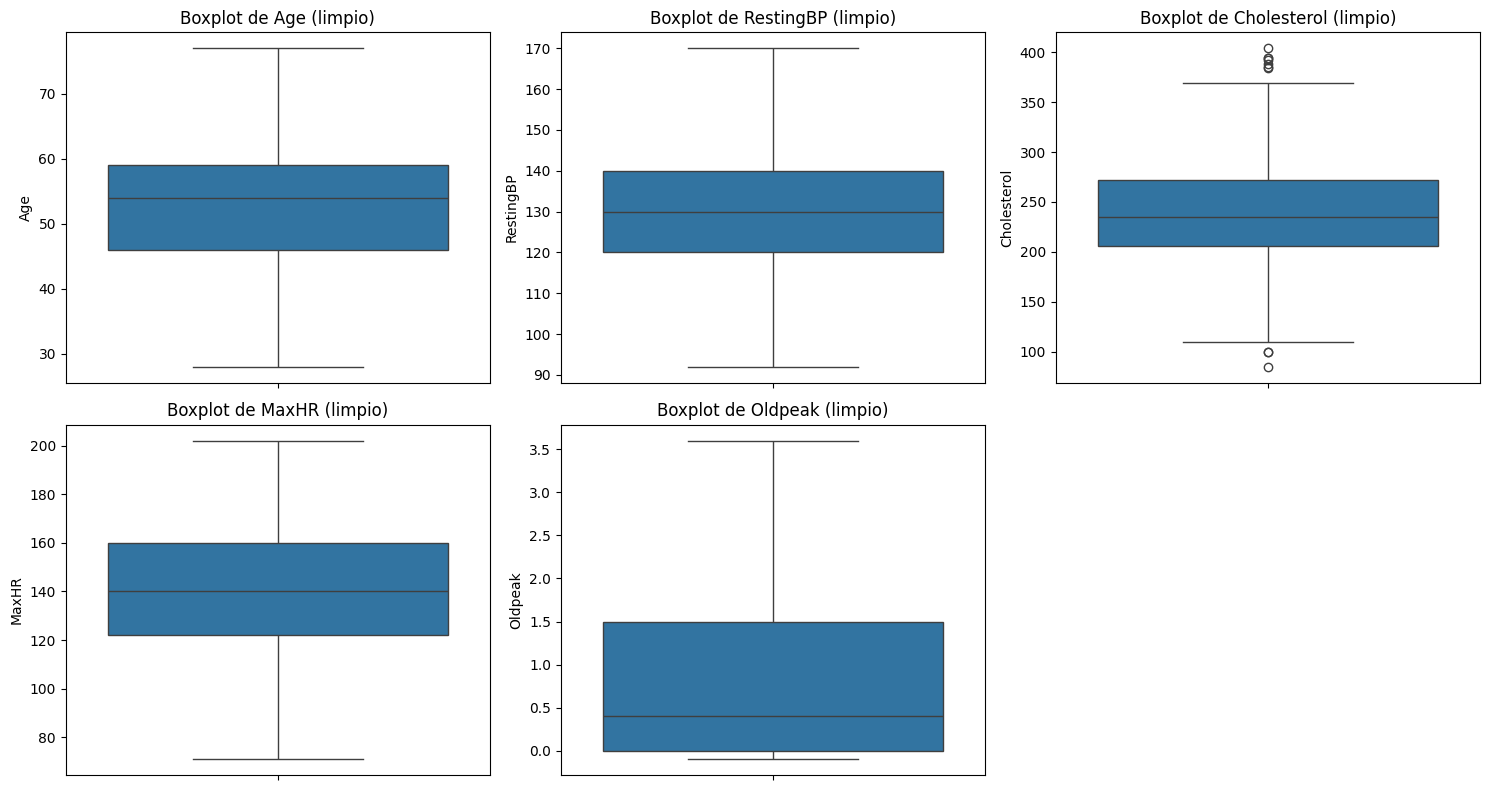

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Seleccionar las columnas numéricas para hacer el análisis
numeric_columns = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Creamos los boxplots para visualizar los datos atipicos
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)  # Crear subimagenes(dos filas de tres columnas, i la posicion de cada grafico)
    sns.boxplot(df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

# Eliminamos los datos atipicos
def remove_outliers(df, columns):
    Q1 = df[columns].quantile(0.25)     #Esta funcion elimina los atipicos devolviendo un df donde estan
    Q3 = df[columns].quantile(0.75)     #los que NO se encuentran en un rango superior desde q3 o q1, una vez y media 
    IQR = Q3 - Q1                       #su diferencia para arriba o abajo segun corresponda
    return df[~((df[columns] < (Q1 - 1.5 * IQR)) | (df[columns] > (Q3 + 1.5 * IQR))).any(axis=1)]   

# Eliminar outliers
df = remove_outliers(df, numeric_columns)

# Mostramos los boxplots nuevamente para visualizar que no están los datos atipicos
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(df[col])
    plt.title(f'Boxplot de {col} (limpio)')
plt.tight_layout()
plt.show()

In [8]:
df.info() # Dataframe limpio de datos atipicos

<class 'pandas.core.frame.DataFrame'>
Index: 702 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             702 non-null    int64  
 1   Sex             702 non-null    int64  
 2   ChestPainType   702 non-null    int64  
 3   RestingBP       702 non-null    int64  
 4   Cholesterol     702 non-null    int64  
 5   FastingBS       702 non-null    int64  
 6   RestingECG      702 non-null    int64  
 7   MaxHR           702 non-null    int64  
 8   ExerciseAngina  702 non-null    int64  
 9   Oldpeak         702 non-null    float64
 10  ST_Slope        702 non-null    int64  
 11  HeartDisease    702 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 71.3 KB


In [9]:
nulos_por_columna = df.isnull().sum()
print(nulos_por_columna) # verificamos que no hayan datos nulos

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [10]:
#NORMALIZACION DE LOS DATOS SEPARAMOS LAS COLUMNAS BINARIAS, LAS CATEGORICAS Y LAS NUMERICAS PARA NORMALIZARLAS.

# saco las variables binarias para trabajar con categoricas y numericas
columnas_binarias=df[['Sex','ExerciseAngina','FastingBS','HeartDisease']]
df=df.drop(columns=['Sex','ExerciseAngina','FastingBS','HeartDisease'])

#normalizacion de categoricas segun su maximo
df['ChestPainType']=df['ChestPainType']/df['ChestPainType'].max()
df['RestingECG']=df['RestingECG']/df['RestingECG'].max()  
df['ST_Slope']=df['ST_Slope']/df['ST_Slope'].max()
columnas_categoricas=df[['ChestPainType','RestingECG','ST_Slope']]
df=df.drop(columns=['ChestPainType','RestingECG','ST_Slope']) # saco las variables categoricas para trabajar con las numericas solo

# normalizacion de numericas segun promedio y desviacion standar
df_stats = df.describe().T
df = (df - df_stats['mean']) / df_stats['std']  
df[['ChestPainType','RestingECG','ST_Slope']]=columnas_categoricas #agrego nuevamente las categoricas
df[['Sex','ExerciseAngina','FastingBS','HeartDisease']]=columnas_binarias #agrego nuevamente las binarias
df.describe()



,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,ChestPainType,RestingECG,ST_Slope,Sex,ExerciseAngina,FastingBS,HeartDisease
count,7.020000e+02,7.020000e+02,7.020000e+02,7.020000e+02,7.020000e+02,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000
mean,8.097353e-17,3.061812e-16,1.088082e-16,-5.465713e-16,9.109522e-17,0.715100,0.316952,0.717949,0.760684,0.374644,0.162393,0.462963
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.318794,0.419272,0.290491,0.426970,0.484376,0.369074,0.498982
min,-2.592694e+00,-2.565242e+00,-3.052424e+00,-2.854969e+00,-9.699717e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.049797e-01,-7.494620e-01,-6.650881e-01,-7.614576e-01,-8.657759e-01,0.333333,0.000000,0.500000,1.000000,0.000000,0.000000,0.000000
50%,1.340044e-01,-1.009691e-01,-9.291672e-02,-2.257124e-02,-4.489923e-01,0.666667,0.000000,0.500000,1.000000,0.000000,0.000000,0.000000
75%,6.583695e-01,5.475239e-01,6.370950e-01,7.984136e-01,6.971626e-01,1.000000,0.500000,1.000000,1.000000,1.000000,0.000000,1.000000
max,2.546084e+00,2.493003e+00,3.241461e+00,2.522482e+00,2.885276e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


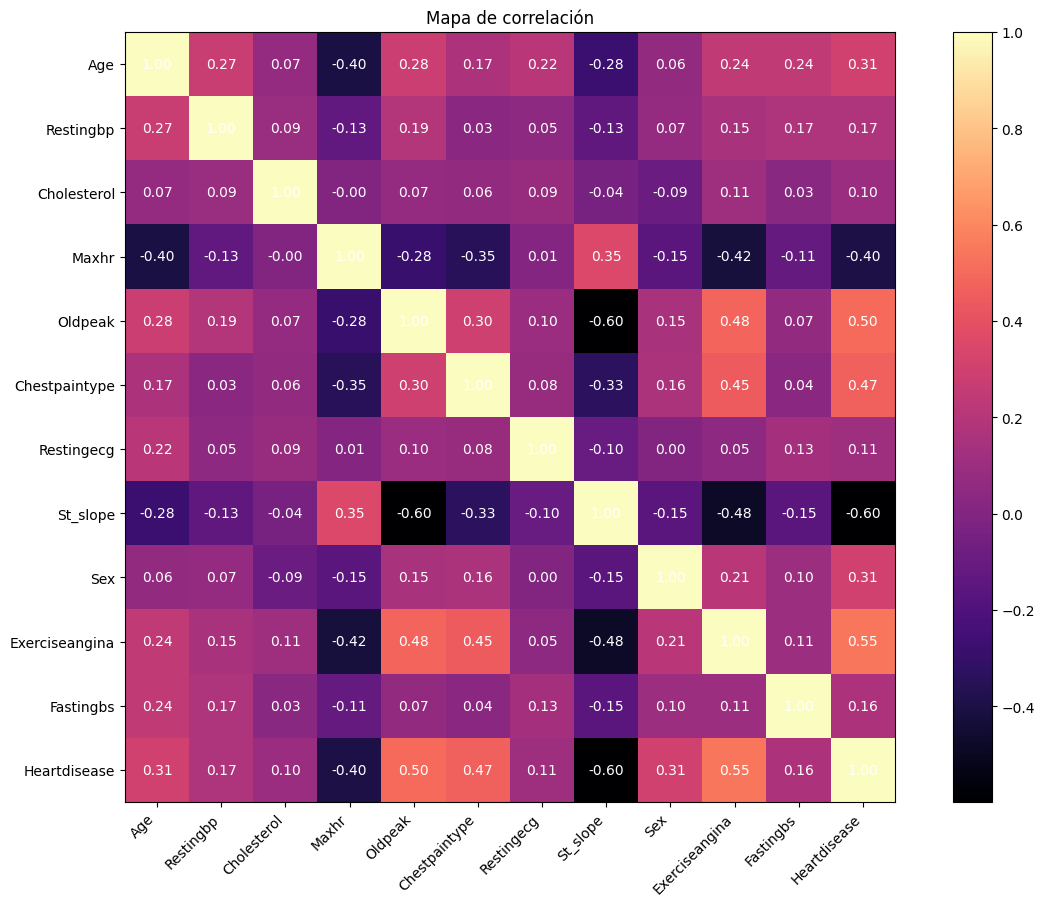

In [11]:
import numpy as np
import matplotlib.pyplot as plt

#separamos las columnas y ponemos mayuscula
labels = [label.capitalize() for label in df.columns.to_list()]


# crear la figura y los ejes
fig, ax = plt.subplots(figsize=(15, 10))

# Seteamaos el mapa de calor 
cax = ax.imshow(df.corr().to_numpy(), cmap='magma')
#Guardamos las correlaciones del df
corr_matrix=df.corr().to_numpy()
# Seteamos los visual 
ax.set_title('Mapa de correlación')
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels, ha='right')
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', color='white')
# Agregamos la escala de color
fig.colorbar(cax, ax=ax)

plt.show()

# Red Neuronal

In [12]:
from sklearn.model_selection import train_test_split

# Seteamos las columnas de entrada y de salida
all_inputs = (df.iloc[:, 0:11].values)
all_outputs = df.iloc[:, -1].values
# Dividimos los conjuntos de datos de entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(all_inputs, all_outputs,
    test_size=1/3)
n_train = X_train.shape[0]
n_test = X_test.shape[0]

In [ ]:
import numpy as np
import pandas as pd


L = .01 # La tasa de aprendizaje


np.random.seed(0)
# Construir red neuronal con pesos y sesgos
# inicializados aleatoriamente
w_hidden = np.random.rand(9, 11)*2-1
w_output = np.random.rand(1, 9)*2-1

b_hidden = np.random.rand(9, 1)*2-1    #Se multiplica por d2 y se resta 1 para tener un rango de -1 a 1 
b_output = np.random.rand(1, 1)*2-1     #y permitir trabajar con negativos tambien

# Funciones de activación
relu = lambda x: np.maximum(x, 0)
logistic = lambda x: 1 / (1 + np.exp(-x))

# Ejecutar entradas a través de la red neuronal para obtener salidas predichas
def forward_prop(X):
    Z1 = w_hidden @ X + b_hidden
    A1 = relu(Z1)
    Z2 = w_output @ A1 + b_output
    A2 = logistic(Z2)
    return Z1, A1, Z2, A2

# Derivadas de las funciones de activación
d_relu = lambda x: x > 0
d_logistic = lambda x: np.exp(-x) / (1 + np.exp(-x)) ** 2

# Devuelve pendientes para pesos y sesgos
# usando la regla de la cadena
def backward_prop(Z1, A1, Z2, A2, X, Y):
    dC_dA2 = 2 * A2 - 2 * Y
    dA2_dZ2 = d_logistic(Z2)
    dZ2_dA1 = w_output
    dZ2_dW2 = A1
    dZ2_dB2 = 1
    dA1_dZ1 = d_relu(Z1)
    dZ1_dW1 = X
    dZ1_dB1 = 1

    dC_dW2 = dC_dA2 @ dA2_dZ2 @ dZ2_dW2.T

    dC_dB2 = dC_dA2 @ dA2_dZ2 * dZ2_dB2

    dC_dA1 = dC_dA2 @ dA2_dZ2 @ dZ2_dA1

    dC_dW1 = dC_dA1 @ dA1_dZ1 @ dZ1_dW1.T

    dC_dB1 = dC_dA1 @ dA1_dZ1 * dZ1_dB1

    return dC_dW1, dC_dB1, dC_dW2, dC_dB2

accuracy_train_l=[]
# listas para graficar luego
accuracy_test_l=[]
# Ejecutar descenso de gradiente
for i in range(12500):
    # seleccionar aleatoriamente uno de los datos de entrenamiento
    idx = np.random.choice(n_train, 1, replace=False)
    X_sample = X_train[idx].transpose()
    Y_sample = Y_train[idx]

    # pasar datos seleccionados aleatoriamente a través de la red neuronal
    Z1, A1, Z2, A2 = forward_prop(X_sample)

    # distribuir error a través de la retropropagación
    # y devolver pendientes para pesos y sesgos
    dW1, dB1, dW2, dB2 = backward_prop(Z1, A1, Z2, A2, X_sample, Y_sample)

    # actualizar pesos y sesgos
    w_hidden -= L * dW1
    b_hidden -= L * dB1
    w_output -= L * dW2
    b_output -= L * dB2
    
    train_predictions = forward_prop(X_train.transpose())[3] # me interesa solo la capa de salida, A2
    train_comparisons = np.equal((train_predictions >=.5).flatten().astype(int), np.array(Y_train>=.5).astype(int))
    accuracy_train = sum(train_comparisons.astype(int) / X_train.shape[0])
    accuracy_train_l.append(accuracy_train)
        
    test_predictions = forward_prop(X_test.transpose())[3] # me interesa solo la capa de salida, A2
    test_comparisons = np.equal((test_predictions >=.5).flatten().astype(int), np.array(Y_test>=.5).astype(int))
    accuracy_test = sum(test_comparisons.astype(int) / X_test.shape[0])
    accuracy_test_l.append(accuracy_test)


print("ACCURACY TRAIN: ", accuracy_train)

print("ACCURACY TEST: ", accuracy_test)

ACCURACY TRAIN:  0.8504273504273481
ACCURACY TEST:  0.8547008547008529


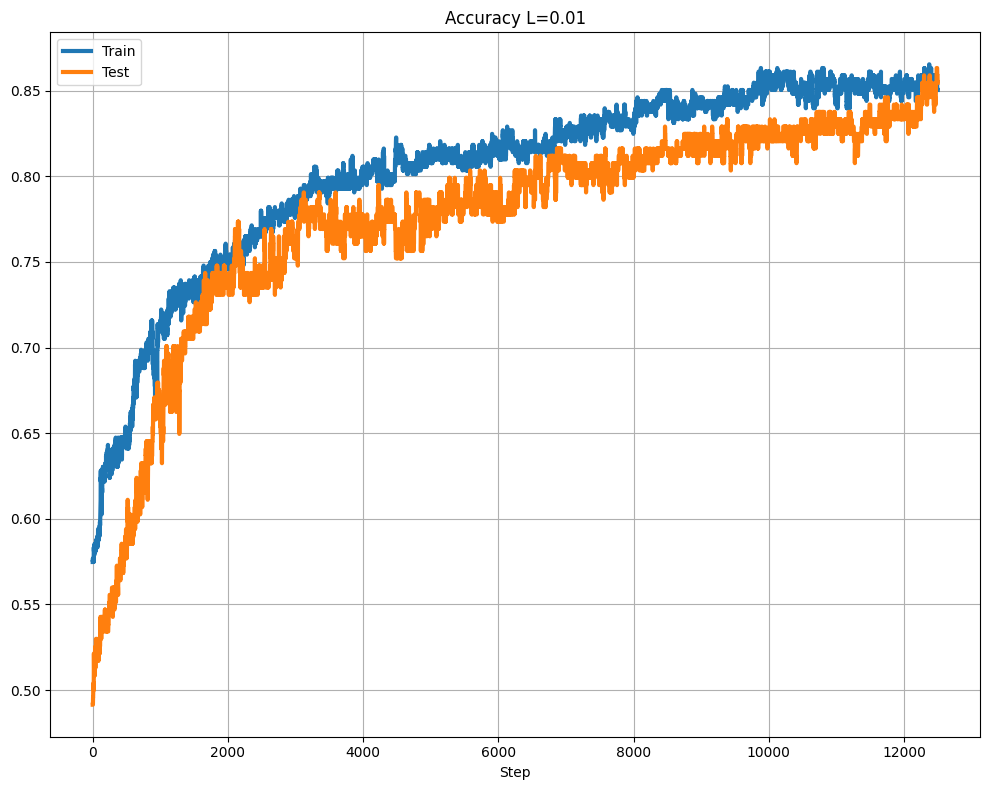

In [14]:
#iters=len(test_l)
fmt_train={
    'color':'tab:blue',
    'ls':'solid',
    'lw':3,
}
fmt_test={
    'color':'tab:orange',
    'ls':'solid',
    'lw':3,
}

fig,(ax)=plt.subplots(1,1,figsize=(10,8))

ax.plot(accuracy_train_l,label='Train',**fmt_train)
ax.plot(accuracy_test_l,label='Test',**fmt_test)

ax.grid(which='both')
ax.legend()
ax.set_title(f'Accuracy {L=}')
ax.set_xlabel('Step')

fig.tight_layout()

In [ ]:

import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier


nn=MLPClassifier(
    solver='sgd',
    hidden_layer_sizes=(9,),
    activation='relu',
    max_iter=12500,
    learning_rate_init=.01,
)

nn.fit(X_train, Y_train)
print(nn.score(X_train,Y_train))
print(nn.score(X_test,Y_test))


0.8717948717948718
0.8547008547008547


# Buscar mejor L e Iteraciones

In [ ]:
import matplotlib.pyplot as plt

def graficar_accuracy(L,train_l,test_l):
    fmt_train={
        'color':'tab:blue',
        'ls':'solid',
        'lw':3,
    }
    fmt_test={
        'color':'tab:orange',
        'ls':'solid',
        'lw':3,
    }
    
    fig,(ax)=plt.subplots(1,1,figsize=(10,8))
    
    ax.plot(train_l,label='Train',**fmt_train)
    ax.plot(test_l,label='Test',**fmt_test)
    
    ax.grid(which='both')
    ax.legend()
    ax.set_title(f'Accuracy{L=}')
    ax.set_xlabel('Step')
    
    fig.tight_layout()

In [17]:
def red_neuronal(L,iters):
    import numpy as np
    import pandas as pd


    #L = 0.001  # La tasa de aprendizaje


    np.random.seed(0)
    # Construir red neuronal con pesos y sesgos
    # inicializados aleatoriamente
    w_hidden = np.random.rand(9, 11)*2-1
    w_output = np.random.rand(1,9)*2-1

    b_hidden = np.random.rand(9, 1)*2-1
    b_output = np.random.rand(1, 1)*2-1

    # Funciones de activación
    relu = lambda x: np.maximum(x, 0)
    logistic = lambda x: 1 / (1 + np.exp(-x))

    # Ejecutar entradas a través de la red neuronal para obtener salidas predichas
    def forward_prop(X):
        Z1 = w_hidden @ X + b_hidden
        A1 = relu(Z1)
        Z2 = w_output @ A1 + b_output
        A2 = logistic(Z2)
        return Z1, A1, Z2, A2

    # Derivadas de las funciones de activación
    d_relu = lambda x: x > 0
    d_logistic = lambda x: np.exp(-x) / (1 + np.exp(-x)) ** 2

    # Devuelve pendientes para pesos y sesgos
    # usando la regla de la cadena
    def backward_prop(Z1, A1, Z2, A2, X, Y):
        dC_dA2 = 2 * A2 - 2 * Y
        dA2_dZ2 = d_logistic(Z2)
        dZ2_dA1 = w_output
        dZ2_dW2 = A1
        dZ2_dB2 = 1
        dA1_dZ1 = d_relu(Z1)
        dZ1_dW1 = X
        dZ1_dB1 = 1

        dC_dW2 = dC_dA2 @ dA2_dZ2 @ dZ2_dW2.T

        dC_dB2 = dC_dA2 @ dA2_dZ2 * dZ2_dB2

        dC_dA1 = dC_dA2 @ dA2_dZ2 @ dZ2_dA1

        dC_dW1 = dC_dA1 @ dA1_dZ1 @ dZ1_dW1.T

        dC_dB1 = dC_dA1 @ dA1_dZ1 * dZ1_dB1

        return dC_dW1, dC_dB1, dC_dW2, dC_dB2

    accuracy_train_l=[]

    accuracy_test_l=[]
    # Ejecutar descenso de gradiente
    for i in range(iters):
        # seleccionar aleatoriamente uno de los datos de entrenamiento
        idx = np.random.choice(n_train, 1, replace=False)
        X_sample = X_train[idx].transpose()
        Y_sample = Y_train[idx]

        # pasar datos seleccionados aleatoriamente a través de la red neuronal
        Z1, A1, Z2, A2 = forward_prop(X_sample)

        # distribuir error a través de la retropropagación
        # y devolver pendientes para pesos y sesgos
        dW1, dB1, dW2, dB2 = backward_prop(Z1, A1, Z2, A2, X_sample, Y_sample)

        # actualizar pesos y sesgos
        w_hidden -= L * dW1
        b_hidden -= L * dB1
        w_output -= L * dW2
        b_output -= L * dB2
        
        train_predictions = forward_prop(X_train.transpose())[3] # me interesa solo la capa de salida, A2
        train_comparisons = np.equal((train_predictions >= .5).flatten().astype(int), np.array(Y_train>=.5).astype(int))
        accuracy_train = sum(train_comparisons.astype(int) / X_train.shape[0])
        accuracy_train_l.append(accuracy_train)
            
        test_predictions = forward_prop(X_test.transpose())[3] # me interesa solo la capa de salida, A2
        test_comparisons = np.equal((test_predictions >= .5).flatten().astype(int), np.array(Y_test>=.5).astype(int))
        accuracy_test = sum(test_comparisons.astype(int) / X_test.shape[0])
        accuracy_test_l.append(accuracy_test)

    
    graficar_accuracy(L=L,train_l=accuracy_train_l,test_l=accuracy_test_l)


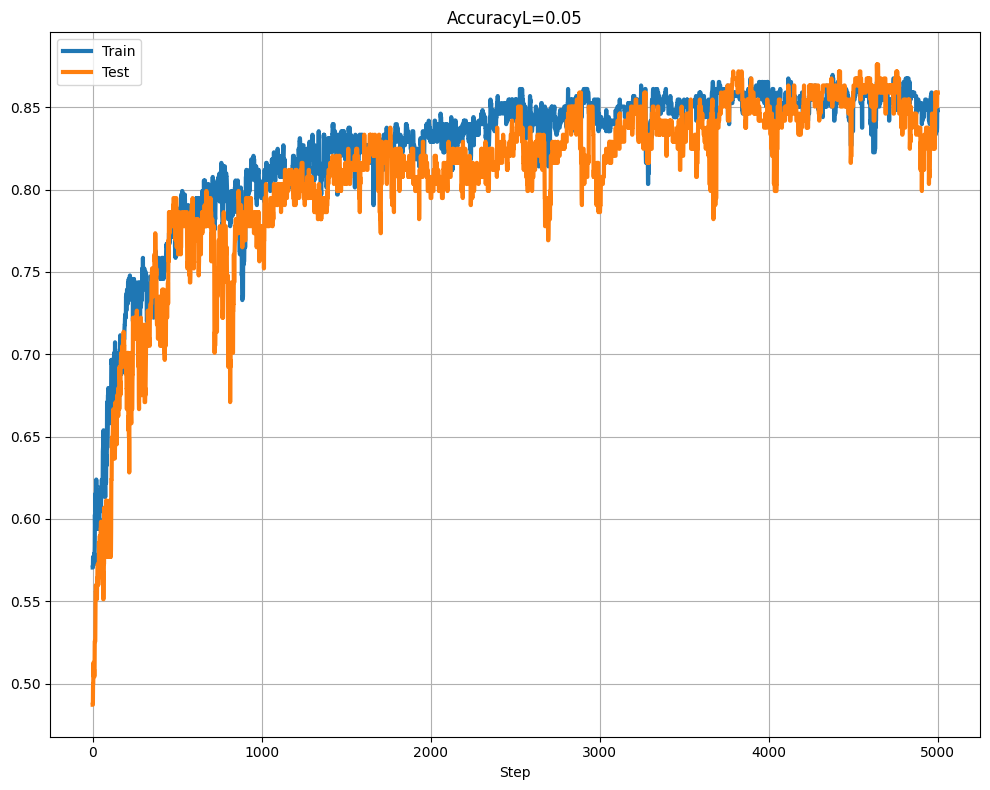

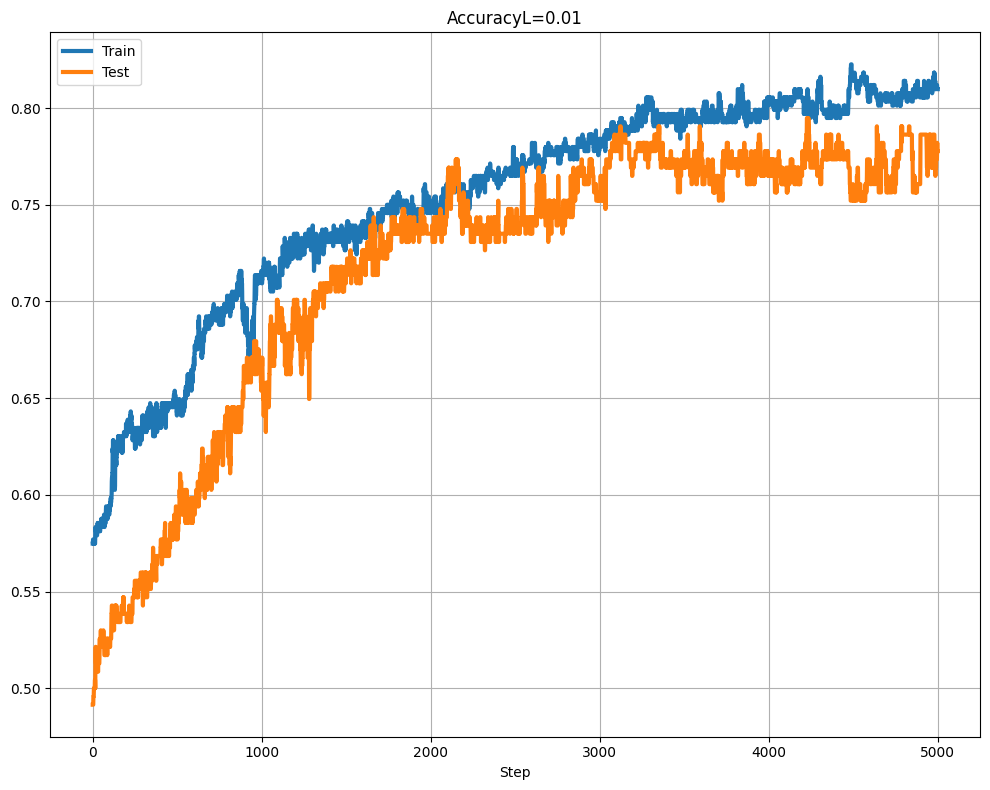

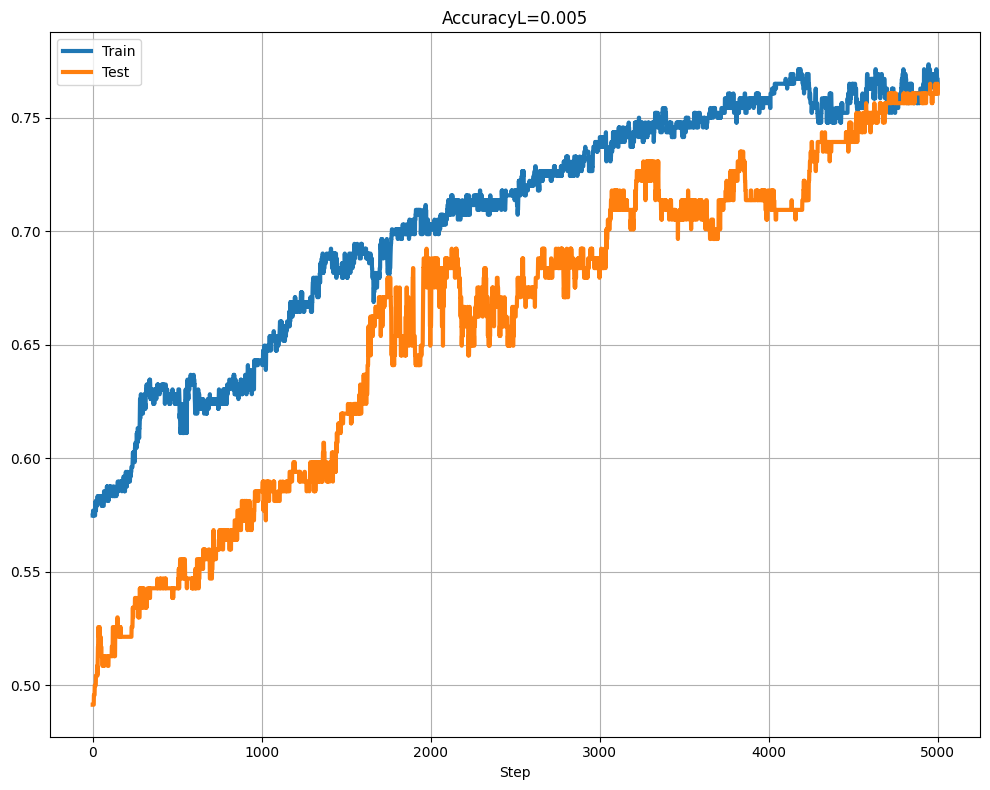

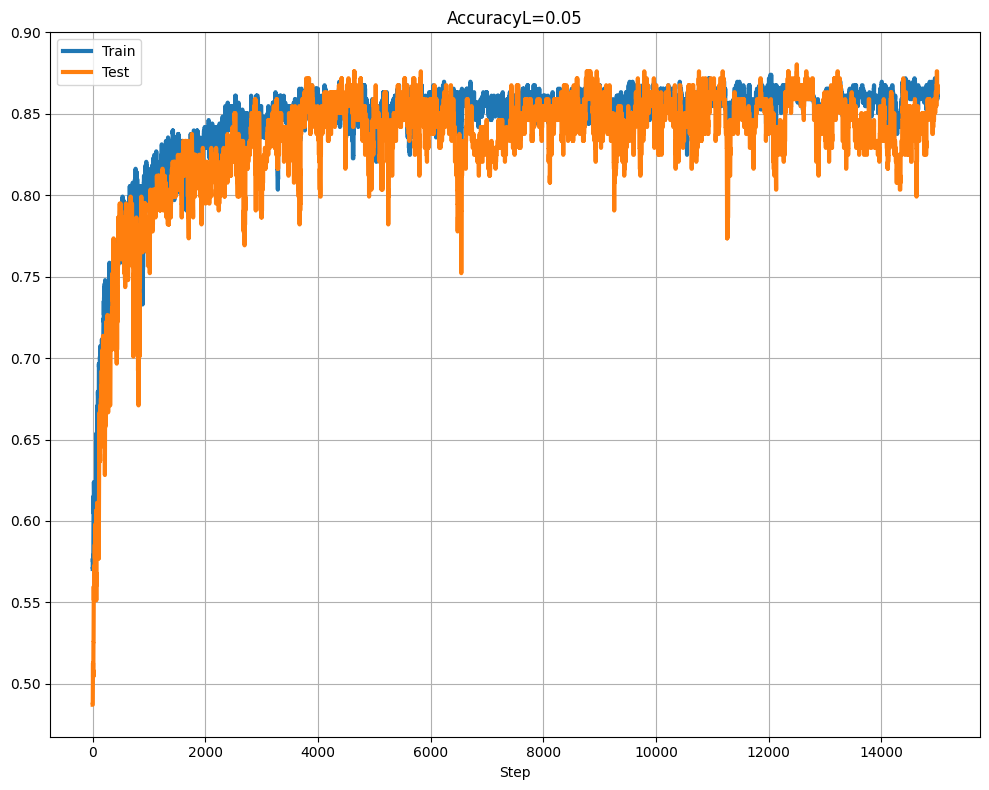

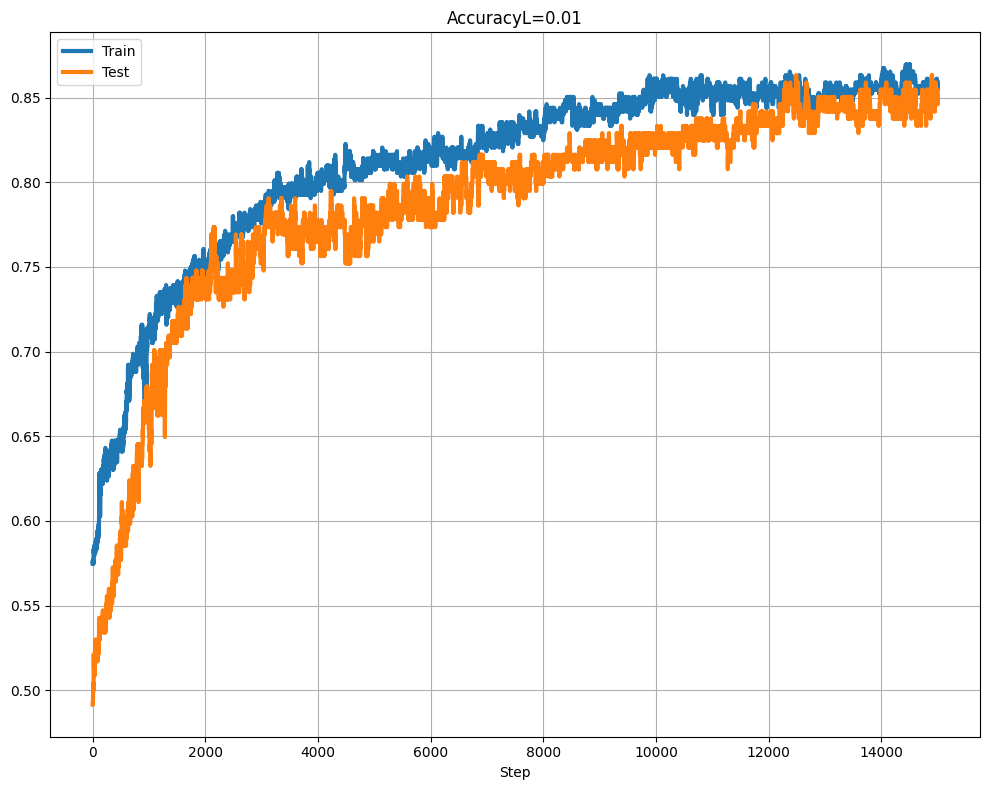

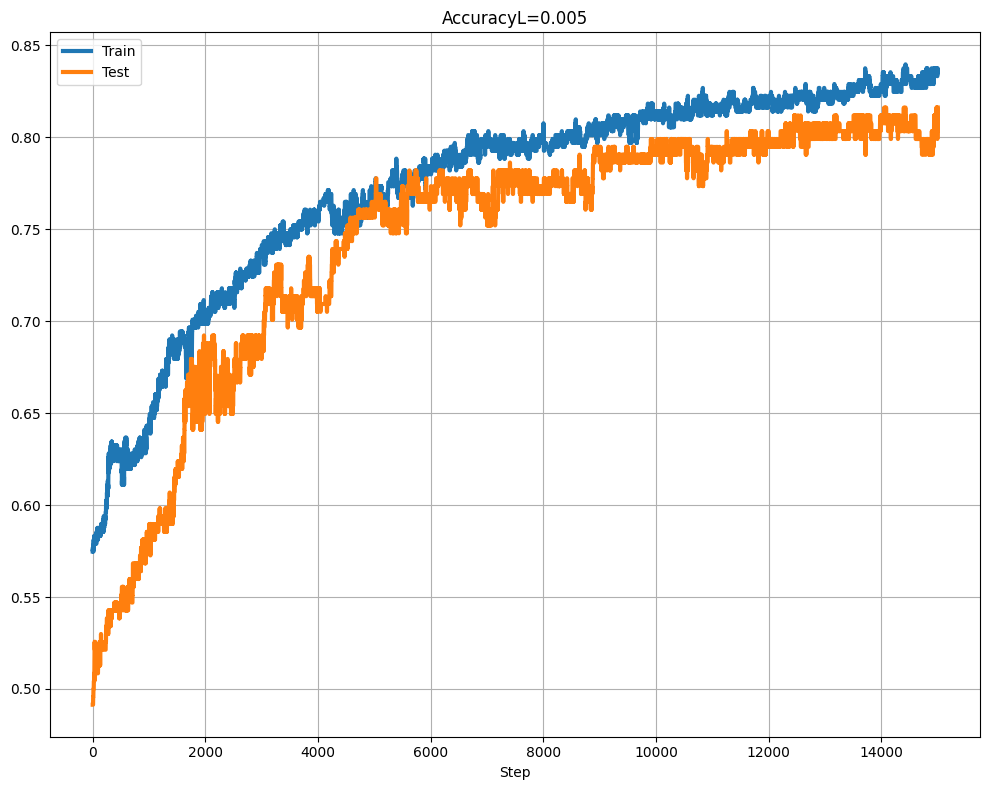

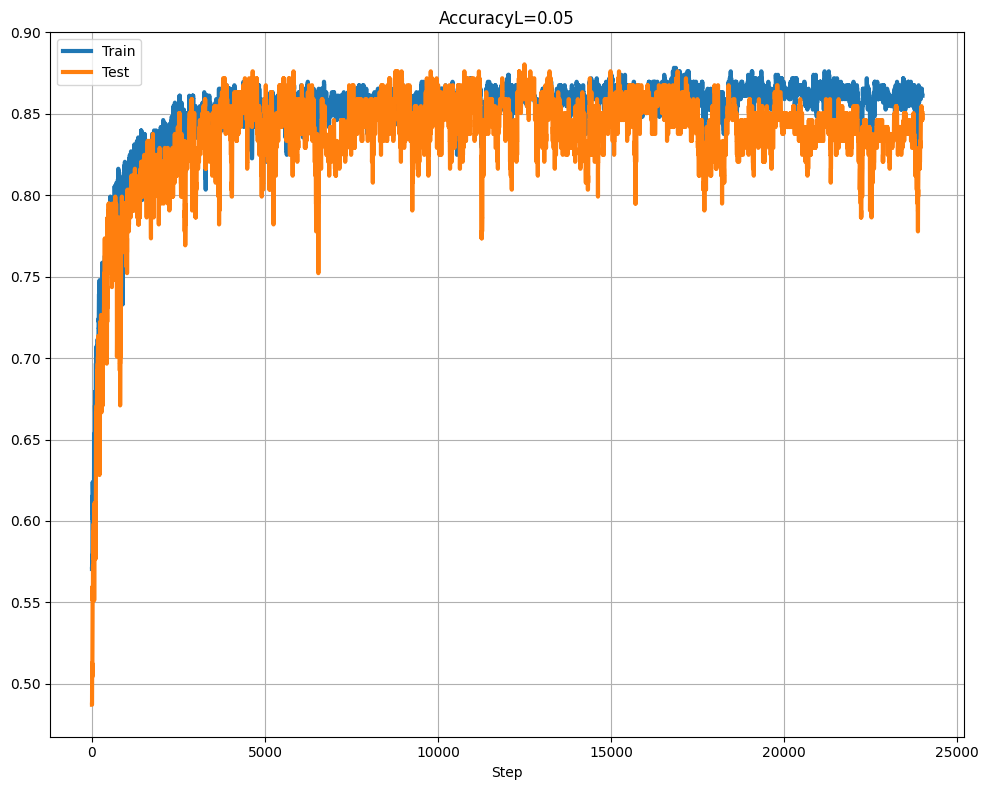

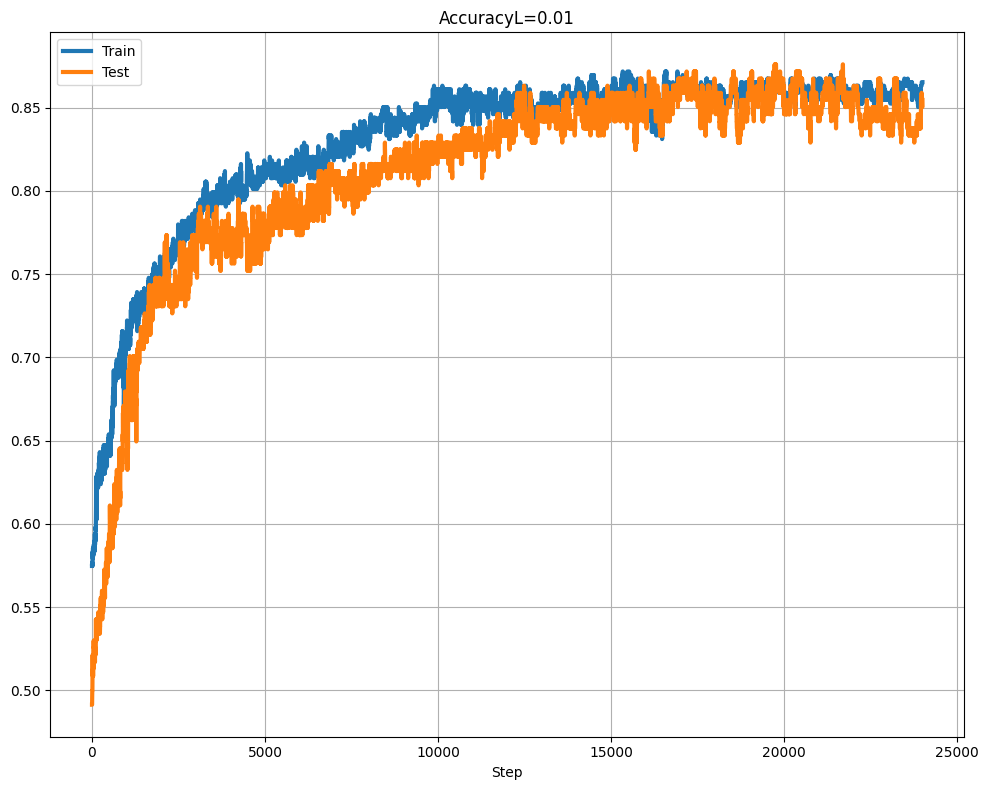

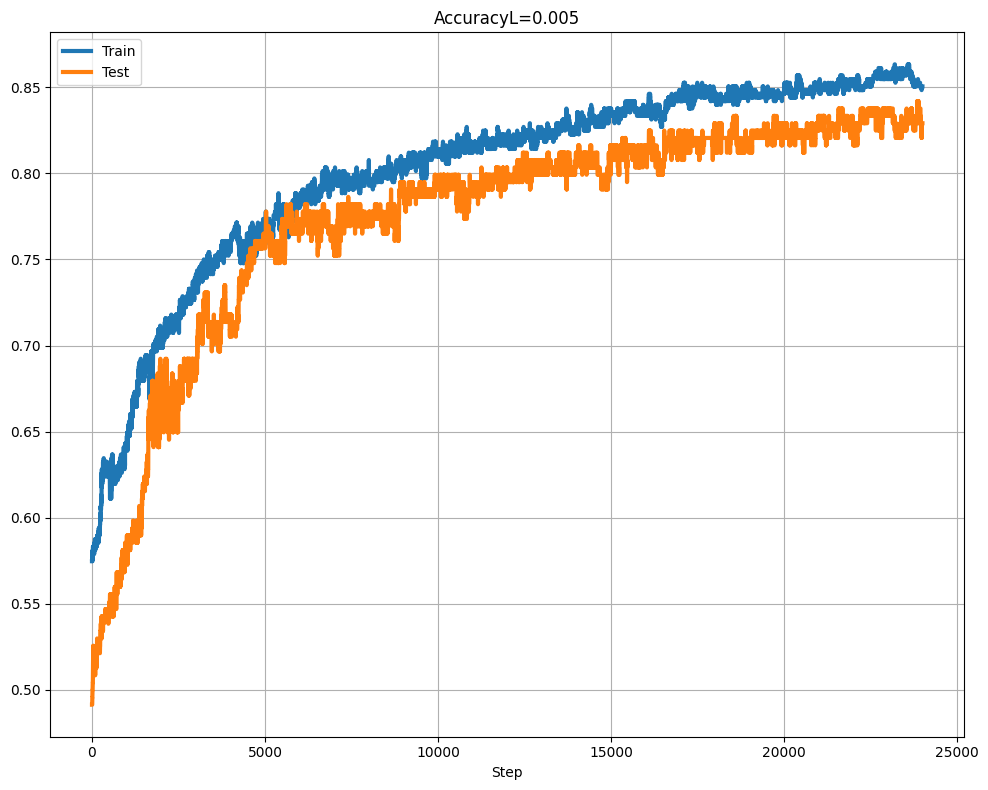

In [18]:
iters_l=[5000,15000,24000]
L_l=[0.05,0.01,0.005]
for iter in iters_l:
    for L in L_l:
        red_neuronal(L=L,iters=iter)